[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_06/TSA_ch6_stock_watson/TSA_ch6_stock_watson.ipynb)

# TSA_ch6_stock_watson

The three-variable VAR of Stock and Watson (2001): inflation (GDP price index), unemployment and the federal funds rate, quarterly 1960Q1-2000Q4, VAR(4), Cholesky order inflation, unemployment, fed funds; impulse responses with bootstrap bands, Granger tests, FEVD, and the same VAR on the extended sample.

*Time Series Analysis (TSA), Chapter 6: VAR models and Granger causality. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_6'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/Quantlets/Ch_06/TSA_ch6_stock_watson


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Analysis

In [5]:
from statsmodels.tsa.api import VAR

from statsmodels.tsa.ar_model import AutoReg

SEED = 2026

GDP_SA = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')

HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')

ROBOR = ('irt_st_m', 'M.IRT_M3.RO')

UNEMP = ('une_rt_m', 'M.SA.TOTAL.PC_ACT.T.RO')

RO_START = '2005-01-01'

RO_VARS = ['g', 'pi', 'i']

RO_P = 2

MKT = ['sp500', 'dax', 'bet']

MKT_START = '2000-01-01'

MKT_P = 4

DY_H, DY_W = 10, 200

SW_VARS = ['pi', 'u', 'R']

SW_START, SW_END, SW_P = '1960-01-01', '2000-10-01', 4

LABEL = {'g': 'GDP growth', 'pi': 'inflation', 'i': 'ROBOR 3M', 'u': 'unemployment', 'ds': 'EUR/RON change', 'R': 'fed funds rate', 'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET'}

COLV = {'g': st.Forest, 'pi': st.IDAred, 'i': st.MainBlue, 'u': st.Purple, 'ds': st.Amber, 'R': st.MainBlue, 'sp500': st.COL['sp500'], 'dax': st.COL['dax'], 'bet': st.COL['bet']}

BAND = st.Teal

WX_A = np.array([[0.5, 0.2], [0.3, 0.4]])

WX_C = np.array([1.2, 0.6])

WX_S = np.array([[1.0, 0.5], [0.5, 1.0]])

WX_Y = np.array([5.0, 2.0])

HERE = "."

def ro_monthly():
    """Romanian monthly series: 12-month HICP inflation, ROBOR 3M, unemployment rate (SA), EUR/RON (monthly mean of the
    BNR reference rate)."""
    hicp = read_eurostat(*HICP)
    fx = load_close('eurron').resample('MS').mean()
    return pd.concat([(100 * np.log(hicp).diff(12)).rename('pi'), read_eurostat(*ROBOR).rename('i'),
                      read_eurostat(*UNEMP).rename('u'), fx.rename('eurron')], axis=1)


def ro_quarterly(start=RO_START):
    """Romanian quarterly data: real GDP growth g (q/q, %, SA), 12-month HICP inflation pi, ROBOR 3M i, unemployment u
    (quarterly means of monthly data) and the EUR/RON change ds = 100 ln(S_t / S_{t-1}) of the quarterly mean rate."""
    m = ro_monthly()
    q = m.resample('QS').mean()
    g = 100 * np.log(read_eurostat(*GDP_SA)).diff()
    d = pd.concat([g.rename('g'), q['pi'], q['i'], q['u'], (100 * np.log(q['eurron']).diff()).rename('ds')], axis=1)
    d.index.name = 'date'
    return d.loc[start:].dropna(subset=['g'])


def ro_var_data(cols=RO_VARS, start=RO_START):
    return ro_quarterly(start)[cols].dropna()


def market_returns(names=MKT, start=MKT_START):
    """Daily log returns (%) of several markets on their common trading days."""
    return load_panel(names, start=start, kind='returns').dropna()


def us_sw(start=SW_START, end=None):
    """Stock and Watson (2001) data from FRED: inflation pi = 400 ln(P_t / P_{t-1}) of the chain-type GDP price index
    (GDPCTPI), the civilian unemployment rate u (UNRATE) and the federal funds rate R (FEDFUNDS), quarterly means."""
    f = read_fred(['GDPCTPI', 'UNRATE', 'FEDFUNDS'])
    pi = 400 * np.log(f['GDPCTPI'].dropna()).diff()
    d = pd.concat([pi.rename('pi'), f['UNRATE'].resample('QS').mean().rename('u'),
                   f['FEDFUNDS'].resample('QS').mean().rename('R')], axis=1).dropna()
    d.index.name = 'date'
    return d.loc[start:end]


def fit_var(d, p):
    m = VAR(d.reset_index(drop=True))
    return m.fit(p)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def years_axis(ax, step=5):
    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def qlabel(ts):
    ts = pd.Timestamp(ts)
    return f'{ts.year}Q{(ts.month - 1) // 3 + 1}'


def ccf(y, x, kmax):
    """Cross-correlations rho_yx(k) = Corr(y_t, x_{t-k}), k = -kmax..kmax (k > 0: x leads y)."""
    return {k: float(pd.Series(y).corr(pd.Series(x).shift(k))) for k in range(-kmax, kmax + 1)}


def companion(res):
    """Companion matrix of a fitted VAR(p) (Kp x Kp)."""
    K, p = res.neqs, res.k_ar
    F = np.zeros((K * p, K * p))
    F[:K, :] = np.hstack(res.coefs)
    if p > 1:
        F[K:, :-K] = np.eye(K * (p - 1))
    return F


def ic_table(d, pmax=8):
    """AIC, BIC and HQ for p = 0..pmax on a common sample (T = N - pmax):
    IC(p) = ln det Sigma_ML(p) + c_T p K^2 / T, with c_T = 2 (AIC), ln T (BIC), 2 ln ln T (HQ)."""
    Y = d.values
    K, N = Y.shape[1], len(Y)
    T = N - pmax
    out = {}
    for p in range(pmax + 1):
        X = np.column_stack([np.ones(T)] + [Y[pmax - j:N - j] for j in range(1, p + 1)])
        Z = Y[pmax:]
        B = np.linalg.lstsq(X, Z, rcond=None)[0]
        U = Z - X @ B
        ld = float(np.log(np.linalg.det(U.T @ U / T)))
        pen = p * K ** 2 / T
        out[p] = {'logdet': ld, 'aic': ld + 2 * pen, 'bic': ld + np.log(T) * pen, 'hq': ld + 2 * np.log(np.log(T)) * pen}
    best = {c: int(min(out, key=lambda p: out[p][c])) for c in ('aic', 'bic', 'hq')}
    return {'T': T, 'K': K, 'pmax': pmax, 'table': out, 'best': best}


def granger_F(d, cause, effect, p):
    """Granger causality F test in the equation of `effect` of a VAR(p) with all variables of d:
    F = [(RSS_R - RSS_U)/p] / [RSS_U/(T - Kp - 1)], RSS_R without the p lags of `cause`."""
    Y = d.values
    cols = list(d.columns)
    K, N = Y.shape[1], len(Y)
    T = N - p
    lags = [Y[p - j:N - j] for j in range(1, p + 1)]
    X = np.column_stack([np.ones(T)] + lags)
    keep = [0] + [1 + (j - 1) * K + k for j in range(1, p + 1) for k in range(K) if cols[k] != cause]
    y = Y[p:, cols.index(effect)]
    rss = lambda Xm: float(np.sum((y - Xm @ np.linalg.lstsq(Xm, y, rcond=None)[0]) ** 2))
    rss_u, rss_r = rss(X), rss(X[:, keep])
    df2 = T - K * p - 1
    F = ((rss_r - rss_u) / p) / (rss_u / df2)
    return {'F': float(F), 'p': float(stats.f.sf(F, p, df2)), 'rss_u': rss_u, 'rss_r': rss_r, 'T': T, 'df1': p,
            'df2': df2, 'crit5': float(stats.f.ppf(0.95, p, df2))}


def granger_table(d, p):
    cols = list(d.columns)
    return {f'{c}->{e}': granger_F(d, c, e, p) for c in cols for e in cols if c != e}


def girf(res, H):
    """Generalised impulse responses (Pesaran and Shin 1998): response at horizon h to a shock of one standard deviation
    in variable j, Phi_h Sigma e_j / sqrt(sigma_jj). Array (H+1, K, K): [h, response, shock]."""
    S = np.asarray(res.sigma_u)
    ma = res.ma_rep(H)
    return np.array([ma[h] @ S / np.sqrt(np.diag(S))[None, :] for h in range(H + 1)])


def gfevd(res, H=DY_H):
    """Generalised FEVD normalised by rows (Diebold and Yilmaz 2012): theta[i, j] = share of the H-step forecast error
    variance of variable i due to shocks in variable j."""
    S = np.asarray(res.sigma_u)
    ma = res.ma_rep(H - 1)
    num = sum((ma[h] @ S) ** 2 for h in range(H)) / np.diag(S)[None, :]
    den = sum(np.diag(ma[h] @ S @ ma[h].T) for h in range(H))
    th = num / den[:, None]
    return th / th.sum(axis=1, keepdims=True)


def spill_index(th):
    K = th.shape[0]
    return 100 * (th.sum() - np.trace(th)) / K


def ar_forecast(y, h, pmax=4):
    """h-step forecast of an AR(p) with constant, p chosen by AIC (p <= pmax), iterated."""
    best = min(range(1, pmax + 1), key=lambda p: AutoReg(y, lags=p, trend='c').fit().aic)
    r = AutoReg(y, lags=best, trend='c').fit()
    return float(r.forecast(h)[-1]), best


def dm_test(e1, e2, h=1):
    """Diebold-Mariano test of equal squared-error loss, with a Newey-West variance of h-1 lags; returns (DM, p)."""
    dl = np.asarray(e1) ** 2 - np.asarray(e2) ** 2
    n = len(dl)
    m = dl.mean()
    g = [np.sum((dl[k:] - m) * (dl[:n - k] - m)) / n for k in range(h)]
    v = (g[0] + 2 * sum(g[1:])) / n
    dm = m / np.sqrt(v)
    return float(dm), float(2 * stats.norm.sf(abs(dm)))


def boot_irf(res, H, repl=500, signif=0.10, seed=SEED):
    """Residual bootstrap bands for orthogonalised impulse responses: resample the VAR residuals with replacement,
    rebuild the series from the first p observations, re-estimate the VAR(p), recompute the responses;
    percentile band of level 1 - signif."""
    rng = np.random.default_rng(seed)
    p, K = res.k_ar, res.neqs
    Y = np.asarray(res.endog)
    U = np.asarray(res.resid)
    U = U - U.mean(axis=0)
    c, A = res.intercept, res.coefs
    draws = []
    for _ in range(repl):
        y = np.zeros_like(Y)
        y[:p] = Y[:p]
        e = U[rng.integers(0, len(U), len(Y) - p)]
        for t in range(p, len(Y)):
            y[t] = c + sum(A[j] @ y[t - 1 - j] for j in range(p)) + e[t - p]
        draws.append(VAR(y).fit(p).irf(H).orth_irfs)
    draws = np.array(draws)
    return np.quantile(draws, signif / 2, axis=0), np.quantile(draws, 1 - signif / 2, axis=0)


def irf_panel(res, names, H, fname, title, repl=500, signif=0.10, save_it=True, scale=None):
    """Orthogonalised impulse responses (K x K panels) with residual-bootstrap bands."""
    irf = res.irf(H)
    lo, hi = boot_irf(res, H, repl, signif)
    K = len(names)
    fig, ax = plt.subplots(K, K, figsize=(10.0, 6.0), sharex=True)
    h = np.arange(H + 1)
    for i in range(K):
        for j in range(K):
            a = ax[i, j]
            a.fill_between(h, lo[:, i, j], hi[:, i, j], color=BAND, alpha=0.25,
                           label=f'{int(100 * (1 - signif))}% band' if (i, j) == (0, 0) else '_nolegend_')
            a.plot(h, irf.orth_irfs[:, i, j], color=COLV[names[j]], lw=1.6,
                   label='orthogonalised response' if (i, j) == (0, 0) else '_nolegend_')
            a.axhline(0, color=st.DarkText, lw=0.6)
            a.set_title(f'{LABEL[names[i]]} <- {LABEL[names[j]]} shock', fontsize=11)
            a.tick_params(labelsize=10)
            a.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    for a in ax[-1]:
        a.set_xlabel('quarters' if H < 50 else 'days', fontsize=11)
    fig.suptitle(title, fontsize=13)
    st.fig_legend_bottom(fig, ncol=2, y=-0.01)
    plt.tight_layout()
    save(fname, save_it)
    return irf.orth_irfs, lo, hi


def ro_fit(p=RO_P, cols=RO_VARS):
    return fit_var(ro_var_data(cols), p)


def fig_us_data(save_it=True):
    d = us_sw(SW_START)
    fig, ax = plt.subplots(figsize=(10.0, 3.6))
    for c, col in [('pi', st.IDAred), ('u', st.Purple), ('R', st.MainBlue)]:
        ax.plot(d.index, d[c], color=col, lw=1.1, label={'pi': 'inflation (GDP price index, annualised %)',
                                                           'u': 'unemployment rate (%)', 'R': 'federal funds rate (%)'}[c])
    ax.axvspan(pd.Timestamp(SW_START), pd.Timestamp(SW_END), color=st.Teal, alpha=0.08, label='Stock-Watson sample 1960-2000')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    years_axis(ax, 5)
    ax.set_title('United States, quarterly, FRED')
    st.legend_outside_bottom(ax, ncol=2)
    plt.tight_layout()
    save('tsa_ch6_us_data', save_it)
    return {'first': qlabel(d.index[0]), 'last': qlabel(d.index[-1]), 'T_sw': len(us_sw(SW_START, SW_END)),
            'T_all': len(d)}


def fig_sw_irf(H=24, save_it=True):
    d = us_sw(SW_START, SW_END)
    r = fit_var(d, SW_P)
    o, lo, hi = irf_panel(r, SW_VARS, H, 'tsa_ch6_sw_irf', 'Stock-Watson VAR(4), 1960Q1-2000Q4, order: inflation, unemployment, fed funds',
                          save_it=save_it)
    G = granger_table(d, SW_P)
    fe = r.fevd(12).decomp
    full = us_sw(SW_START)
    rf = fit_var(full, SW_P)
    of = rf.irf(H).orth_irfs
    Gf = granger_table(full, SW_P)
    k = {c: j for j, c in enumerate(SW_VARS)}
    return {'granger': {kk: v['p'] for kk, v in G.items()}, 'granger_full': {kk: v['p'] for kk, v in Gf.items()},
            'fevd': {c: {str(hh): (100 * fe[k[c], hh - 1, :]).tolist() for hh in (1, 4, 8, 12)} for c in SW_VARS},
            'u_R': o[:, k['u'], k['R']].tolist(), 'pi_R': o[:, k['pi'], k['R']].tolist(), 'R_R': o[:, k['R'], k['R']].tolist(),
            'R_pi': o[:, k['R'], k['pi']].tolist(), 'R_u': o[:, k['R'], k['u']].tolist(),
            'u_R_full': of[:, k['u'], k['R']].tolist(), 'pi_R_full': of[:, k['pi'], k['R']].tolist(),
            'sig_pi_R': [bool(lo[h, 0, 2] > 0 or hi[h, 0, 2] < 0) for h in range(H + 1)],
            'sig_u_R': [bool(lo[h, 1, 2] > 0 or hi[h, 1, 2] < 0) for h in range(H + 1)],
            'max_mod': float(np.abs(np.linalg.eigvals(companion(r))).max()),
            'max_mod_full': float(np.abs(np.linalg.eigvals(companion(rf))).max()), 'T': int(r.nobs),
            'T_full': int(rf.nobs), 'last_full': qlabel(full.index[-1]), 'n_coef': int(r.params.size)}

## Run

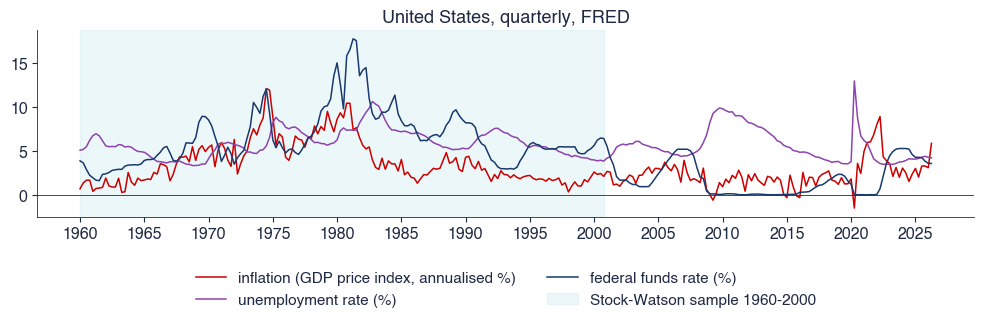

{'first': '1960Q1', 'last': '2026Q2', 'T_sw': 164, 'T_all': 266}


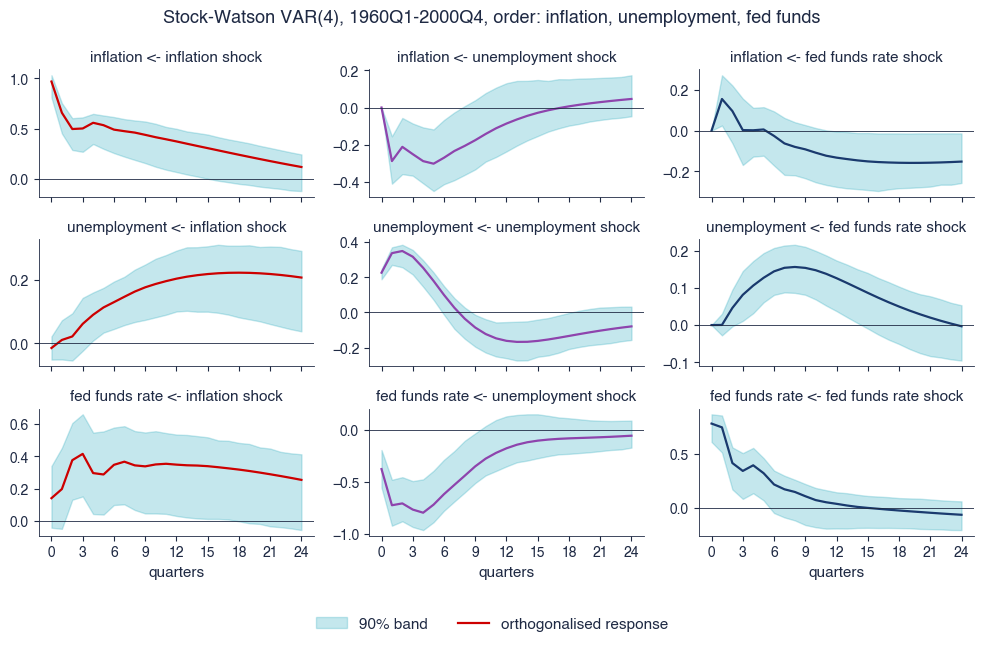

{'granger': {'pi->u': 0.21009790546691196, 'pi->R': 0.00012597686230033763, 'u->pi': 0.035800817887519, 'u->R': 1.3477275014139278e-05, 'R->pi': 0.4016677154972799, 'R->u': 0.003260526492364505}, 'granger_full': {'pi->u': 0.845380319313038, 'pi->R': 0.007172717679216851, 'u->pi': 0.15309699261823234, 'u->R': 0.3817245201356694, 'R->pi': 0.06300527959661177, 'R->u': 0.018399969673268533}, 'fevd': {'pi': {'1': [100.0, 0.0, 0.0], '4': [89.32057031572627, 9.078274313474337, 1.6011553707994035], '8': [84.70289325313625, 14.192129020182204, 1.1049777266815453], '12': [84.39041746568094, 13.757248649670759, 1.8523338846483064]}, 'u': {'1': [0.4344011434216395, 99.56559885657835, 0.0], '4': [1.1427624778666383, 96.66245211082885, 2.194785411304503], '8': [10.030856280658778, 77.26919142218365, 12.699952297157575], '12': [21.64965762499009, 59.52359232217157, 18.826750052838342]}, 'R': {'1': [2.558017318693829, 18.67142316916553, 78.77055951214064], '4': [10.349960314094416, 49.197246054227314,

In [6]:
print(fig_us_data())
print(fig_sw_irf())

![tsa_ch6_us_data](./tsa_ch6_us_data.png)

Output: `tsa_ch6_us_data.pdf`

![tsa_ch6_sw_irf](./tsa_ch6_sw_irf.png)

Output: `tsa_ch6_sw_irf.pdf`